In [122]:
# bloco de código para as funções
import random
telemetria = list()
for c in range(50): # laço para gerar 50 "temperaturas" para serem analisadas
  telemetria.append(f'{random.triangular(-150, 150):.2f}') # valores entre -150 e 150 para tratar dados inválidos
print(telemetria)

# validar temperatura
def validar_temperatura(t):
  if float(t) < -100 or float(t) > 120:
    return False
  else:
    return True

# classificar temperatura
def classificar_temperatura(t):
  categoria = ''
  if float(t) < -40:
    categoria = 'Cold Case Crítico'
  elif -40 <= float(t) < -20:
    categoria = 'Frio'
  elif -20 <= float(t) <= 50:
    categoria = 'Nominal'
  elif 50 < float(t) <= 70:
    categoria = 'Quente'
  else:
    categoria = 'Hot Case Crítico'
  return categoria

# detectar picos e vales
def detectar_picos_vales(lista):
  pico_vale = list()
  quantidade_picos = 0
  quantidade_vales = 0
  for i in range(1, len(lista) - 1):
    if lista[i - 1] < lista[i] > lista[i + 1]:
      pico_vale.append([i * 3, float(lista[i]), 'Pico'])
      quantidade_picos += 1
    elif lista[i - 1] > lista[i] < lista[i + 1]:
      pico_vale.append([i * 3, float(lista[i]), 'Vale'])
      quantidade_vales += 1
  return pico_vale

# gerar relatorio
def gerar_relatorio(lista):
  cold_case = 0
  frio = 0
  nominal = 0
  quente = 0
  hot_case = 0
  if lista[0][2] == 'Cold Case Crítico' or lista[0][2] == 'Frio' or lista[0][2] == 'Nominal' or lista[0][2] == 'Quente' or lista[0][2] == 'Hot Case Crítico':
    for linha in lista:
      if linha[2] == 'Cold Case Crítico':
        cold_case += 1
      elif linha[2] == 'Frio':
        frio += 1
      elif linha[2] == 'Nominal':
        nominal += 1
      elif linha[2] == 'Quente':
        quente += 1
      elif linha[2] == 'Hot Case Crítico':
        hot_case += 1
    return f'Quantidade de "Cold Case Crítico": {cold_case} ({(cold_case / len(lista)) * 100:.2f}%)\nQuantidade de "Nominal": {nominal} ({(nominal / len(lista)) * 100:.2f}%)\nQuantidade de "Frio": {frio} ({(frio / len(lista)) * 100:.2f}%)\nQuantidade de "Quente": {quente} ({(quente / len(lista)) * 100:.2f}%)\nQuantidade de "Hot Case Crítico": {hot_case} ({(hot_case / len(lista)) * 100:.2f}%)'
  quantidade_picos = 0
  quantidade_vales = 0
  if lista[0][2] == 'Pico' or lista[0][2] == 'Vale':
    for linha in lista:
      if linha[2] == 'Pico':
        quantidade_picos += 1
      elif linha[2] == 'Vale':
        quantidade_vales += 1
  return f'Quantidade de "Picos": {quantidade_picos}\nQuantidade de "Vales": {quantidade_vales}'
  

['69.04', '33.08', '-0.01', '88.18', '-63.90', '-107.03', '20.83', '-67.74', '-20.40', '-96.18', '-88.43', '-27.86', '-9.61', '-85.61', '137.58', '57.51', '69.03', '89.10', '0.72', '-96.19', '116.49', '108.13', '132.70', '-106.03', '79.68', '-52.60', '76.40', '-34.51', '26.50', '32.55', '76.02', '76.18', '-41.00', '47.66', '30.59', '-70.36', '9.00', '84.46', '109.98', '-23.25', '3.24', '-14.02', '-66.79', '-50.32', '52.55', '47.46', '52.07', '-31.77', '-30.43', '55.36']


In [123]:
# 2 validar a temperatura
temperaturas_invalidas = list()
for indice, temperatura in enumerate(telemetria):
  validacao = validar_temperatura(temperatura)
  if validacao == False:
    temperaturas_invalidas.append(temperatura)
    telemetria.pop(indice) # isso causa um bug silencioso, mudar depois

print(telemetria)
if len(temperaturas_invalidas) > 0:
  print(f'A telemetria possuia alguns dados inválidos, que ja foram removidos de nossa telemetria principal.')
  print(f'Restaram {len(telemetria)} dados para serem análisados.')
  print(f'Aqui estão os dados inválidos captados: {temperaturas_invalidas}')
else:
  print('Não foram encontrados dados inválidos na telemetria.')

['69.04', '33.08', '-0.01', '88.18', '-63.90', '20.83', '-67.74', '-20.40', '-96.18', '-88.43', '-27.86', '-9.61', '-85.61', '57.51', '69.03', '89.10', '0.72', '-96.19', '116.49', '108.13', '-106.03', '79.68', '-52.60', '76.40', '-34.51', '26.50', '32.55', '76.02', '76.18', '-41.00', '47.66', '30.59', '-70.36', '9.00', '84.46', '109.98', '-23.25', '3.24', '-14.02', '-66.79', '-50.32', '52.55', '47.46', '52.07', '-31.77', '-30.43', '55.36']
A telemetria possuia alguns dados inválidos, que ja foram removidos de nossa telemetria principal.
Restaram 47 dados para serem análisados.
Aqui estão os dados inválidos captados: ['-107.03', '137.58', '132.70']


In [124]:
# 3 identificar a categoria conforme a tabela de classificação térmica
lista_classificacoes = list()
for indice, temperatura in enumerate(telemetria):
  classificacao = classificar_temperatura(temperatura)
  lista_classificacoes.append([indice * 3, float(temperatura), classificacao])
print('min / Temp. / Class.')
display(lista_classificacoes)
# a lista armazena [minuto, temperatura, classificacao]

min / Temp. / Class.


[[0, 69.04, 'Quente'],
 [3, 33.08, 'Nominal'],
 [6, -0.01, 'Nominal'],
 [9, 88.18, 'Hot Case Crítico'],
 [12, -63.9, 'Cold Case Crítico'],
 [15, 20.83, 'Nominal'],
 [18, -67.74, 'Cold Case Crítico'],
 [21, -20.4, 'Frio'],
 [24, -96.18, 'Cold Case Crítico'],
 [27, -88.43, 'Cold Case Crítico'],
 [30, -27.86, 'Frio'],
 [33, -9.61, 'Nominal'],
 [36, -85.61, 'Cold Case Crítico'],
 [39, 57.51, 'Quente'],
 [42, 69.03, 'Quente'],
 [45, 89.1, 'Hot Case Crítico'],
 [48, 0.72, 'Nominal'],
 [51, -96.19, 'Cold Case Crítico'],
 [54, 116.49, 'Hot Case Crítico'],
 [57, 108.13, 'Hot Case Crítico'],
 [60, -106.03, 'Cold Case Crítico'],
 [63, 79.68, 'Hot Case Crítico'],
 [66, -52.6, 'Cold Case Crítico'],
 [69, 76.4, 'Hot Case Crítico'],
 [72, -34.51, 'Frio'],
 [75, 26.5, 'Nominal'],
 [78, 32.55, 'Nominal'],
 [81, 76.02, 'Hot Case Crítico'],
 [84, 76.18, 'Hot Case Crítico'],
 [87, -41.0, 'Cold Case Crítico'],
 [90, 47.66, 'Nominal'],
 [93, 30.59, 'Nominal'],
 [96, -70.36, 'Cold Case Crítico'],
 [99, 9.0, 

In [125]:
# 4 mapear as inversões de tendência térmica
pv = detectar_picos_vales(telemetria)
display(pv)
# a lista armazena [minuto, temperatura, pico/vale]

[[6, -0.01, 'Vale'],
 [9, 88.18, 'Pico'],
 [12, -63.9, 'Vale'],
 [15, 20.83, 'Pico'],
 [21, -20.4, 'Vale'],
 [24, -96.18, 'Pico'],
 [30, -27.86, 'Vale'],
 [33, -9.61, 'Pico'],
 [36, -85.61, 'Vale'],
 [45, 89.1, 'Pico'],
 [51, -96.19, 'Vale'],
 [54, 116.49, 'Pico'],
 [60, -106.03, 'Vale'],
 [63, 79.68, 'Pico'],
 [66, -52.6, 'Vale'],
 [69, 76.4, 'Pico'],
 [72, -34.51, 'Vale'],
 [84, 76.18, 'Pico'],
 [87, -41.0, 'Vale'],
 [90, 47.66, 'Pico'],
 [96, -70.36, 'Vale'],
 [99, 9.0, 'Pico'],
 [108, -23.25, 'Vale'],
 [111, 3.24, 'Pico'],
 [114, -14.02, 'Vale'],
 [117, -66.79, 'Pico'],
 [120, -50.32, 'Vale'],
 [123, 52.55, 'Pico'],
 [126, 47.46, 'Vale'],
 [129, 52.07, 'Pico'],
 [135, -30.43, 'Vale']]

In [126]:
# 5 gerar o relatório
print(gerar_relatorio(lista_classificacoes))
print()
print(gerar_relatorio(pv))

Quantidade de "Cold Case Crítico": 12 (25.53%)
Quantidade de "Nominal": 13 (27.66%)
Quantidade de "Frio": 6 (12.77%)
Quantidade de "Quente": 6 (12.77%)
Quantidade de "Hot Case Crítico": 10 (21.28%)

Quantidade de "Picos": 15
Quantidade de "Vales": 16


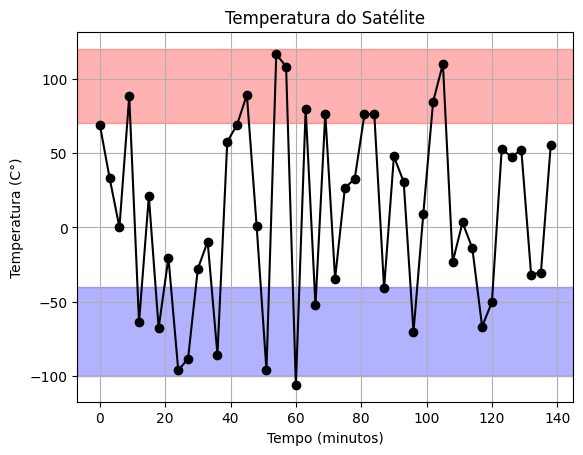

In [127]:
# gerando os graficos usando matplotlib (gemini que me explicou essa loucura)
import matplotlib.pyplot as plt

# eixo X e eixo Y
tempos = [item[0] for item in lista_classificacoes]
temperaturas = [item[1] for item in lista_classificacoes]

# criando a tela do grafico e a area
fig, ax = plt.subplots() # fig é a tela, ax é o quadrado onde os eixos ficam

# fazendo a linha de temperaturas
ax.plot(tempos, temperaturas, color='black', marker='o')

# pintando por frescuragem
ax.axhspan(-100, -40, color='blue', alpha=0.3) # pinta de azul o Code Case Crítico # alpha é a transparencia
# ele começa na altura y = -100 e vai até a altura y = -40
ax.axhspan(70, 120, color='red', alpha=0.3) # pinta de vermelho o Hot Case Crítico
# ele começa na altura y = 70 e vai até a altura y = 120

# colocando textos
ax.set_title('Temperatura do Satélite')
ax.set_xlabel('Tempo (minutos)')
ax.set_ylabel('Temperatura (C°)')

# deixando aquela coisa quadriculada la
ax.grid(True)

# mostrando finalmente o grafico
plt.show()